# Assignment 3: Linear Models

# Namitha Tholasi (cku5zp)

In [104]:
! git clone https://github.com/ds4e/undergrad_ml_assignments

fatal: destination path 'undergrad_ml_assignments' already exists and is not an empty directory.


In [105]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

**A model is called linear if it is linear in its parameters (coefficients β), meaning the coefficients only multiply  variables and are added together, and are not transformed (like not squared, exponentiated, etc). "Linear" refers to the parameters, not necessarily the inputs, so the model can still include nonlinear transformations of x (like x squared or log x) and remain linear.**

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

**The coefficient of a dummy variable represents the difference in the outcome between the group coded as 1 and the baseline group (coded as 0), which is captured by the intercept.**

3. Can linear regression be used for classification? Explain why, or why not.

**Linear regression can technically be used for classification by applying a threshold, but it is not appropriate because it predicts continuous values (not probabilities), can produce outputs outside 0-1, and does not model class boundaries as well.**

4. What are signs that your linear model is over-fitting?

**Signs of overfitting include low training error but high test/validation error, indicating the model fits the training data too closely and does not generalize well to new data.**


5. Clearly explain multi-colinearity using the two-stage least squares technique.

**Multicollinearity occurs when predictors are highly correlated, making coefficients unstable; using a two-stage approach, we first regress a collinear variable on others to isolate its unique (residual) component, then use that in the main regression to remove overlap and obtain more reliable estimates.**


6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

**Nonlinear relationships can be incorporated by transforming the input variables (like adding polynomial, logarithmic, or interaction terms) and including them as features in a linear regression model.**

7. What is the interpretation of the slope coefficient in a linear regression?

**The slope coefficient represents the change in the dependent variable y for a one-unit increase in x, holding all other variables constant.**

8. Compare the train/test split and $k$-fold cross validation.

**Train/test split evaluates a model using a single data split, while k-fold cross-validation repeatedly splits the data into k subsets, trains and tests k times, and averages the results to provide a more reliable estimate of model performance**

9. How is the $k$ in $k$-fold cross validation typically selected?

**The value of k is typically chosen as 5 or 10 to balance computational efficiency and reliable model evaluation.**

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [106]:
#Q2.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder
import statsmodels.api as sm

df = pd.read_csv('./undergrad_ml_assignments/data/Q1_clean.csv')
df.columns = df.columns.str.strip()
df = df.rename(columns={"Neighbourhood": "Neighbourhood"})

                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65

Most expensive: Manhattan


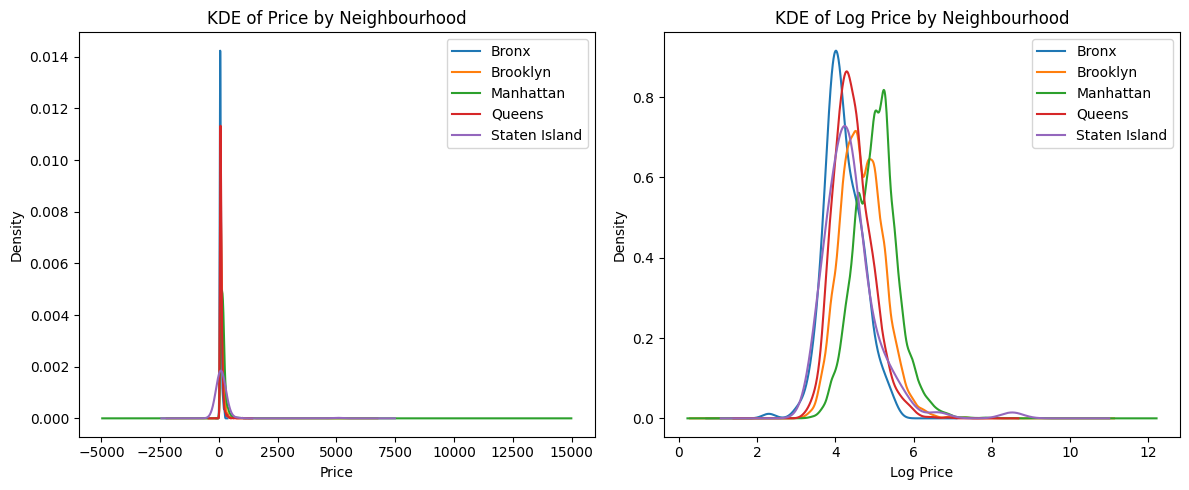

In [107]:
#Q2.1

#Average price and score by neighbourhood
summary = df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]].mean().round(2)
print(summary.sort_values("Price", ascending=False))

#Most expensive borough
most_expensive = summary["Price"].idxmax()
print(f"\nMost expensive: {most_expensive}")

#KDE plots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

for hood, group in df.groupby("Neighbourhood"):
  group["Price"].plot.kde(ax=axes[0], label=hood)
  np.log(group["Price"]).plot.kde(ax=axes[1], label=hood)

axes[0].set_title("KDE of Price by Neighbourhood")
axes[0].set_xlabel("Price")
axes[0].legend()

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.show()

**Q2.1 Answer:**

**Manhattan is the most expensive borough. The raw price distribution is right-skewed, meaning a small number of very expensive listings pull the mean up. Taking the log compresses those large values, making the distribution more symmetric and approximately normal - which is a more useful shape for regression modeling.**

In [108]:
#Q2.2

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True).astype(int)
X = sm.add_constant(dummies)
y = df["Price"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

print("\nGroup means:")
print(df.groupby('Neighbourhood')['Price'].mean())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        20:13:12   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

**Q2.2 Answer:**

**The intercept is the Bronx's average price (reference category), and each coefficent is how much more or less expensive that borough is compared to the Bronx. This means the coefficients are just differences in group means - this can be verified by subtracting the Bronx mean from each other borough's mean in the Q2.1 table and the same numbers are outputted.**

In [109]:
#Q2.3

X3 = sm.add_constant(df["Review Scores Rating"])
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        20:13:12   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

**Q2.3 Answer:**

**The slope coefficient is essentially saying that a one-point increase in Review Scores Rating is associated with a [coefficient] dollar change in Price per night on average.**

In [110]:
#Q2.4

X4 = sm.add_constant(pd.concat([dummies, df["Review Scores Rating"]], axis=1))
model4 = sm.OLS(y, X4).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        20:13:12   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

**Q2.4 Answer:**

**Once we control for neighbourhood, the slope on Review Scores Rating changes because we are now estimating the effects of ratings within each borough, removing the confounding effect of neighbourhood on both price and ratings. The neighbourhood coefficients also shift slightly since they now represent price differences holding rating constant rather than raw group means.**

In [111]:
#Q2.5

df["Rating"] = df["Review Scores Rating"]
X5 = sm.add_constant(
    pd.concat([dummies, df['Rating'],
               dummies.multiply(df['Rating'], axis=0)], axis=1)
)

model5 = sm.OLS(y, X5).fit()
print(model5.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:13:12   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            22.6384    110.171      0.205

**Q2.5 Answer:**

**This model gives each neighbourhood its own slope for Review Scores Rating. If the interaction coefficients are small or insignificant, the relationship between ratings and price is roughly the same across all boroughs - if they differ a lot, ratings matter more in some neighbourhoods than others.**

In [112]:
#Q2.6

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

X4_sk = pd.concat([dummies, df["Rating"]], axis=1).astype(float)
X5_sk = pd.concat([dummies, df["Rating"],
                  dummies.multiply(df['Rating'], axis=0)], axis=1).astype(float)

for name, X in [("Model 4 (neighbourhood + rating)", X4_sk),
                ("Model 5 (interactions)", X5_sk)]:

    scores = cross_val_score(LinearRegression(), X, y, cv=10,
                             scoring="neg_mean_squared_error")

    rsme = np.sqrt(-scores.mean())
    print(f"{name}: CV RSME = {rsme:.2f}")

Model 4 (neighbourhood + rating): CV RSME = 145.24
Model 5 (interactions): CV RSME = 146.02


**Q2.6 Answer:**

**Cross validation gives us an honest estimate of how well each model predicts on unseen data by comparing CV RSME scores - the lower the better. If the interaction model from Q2.5 has a similar or only slightly lower RSME than Q2.4, the added complexity of fitting separate slopes per neighbourhood isn't worth it and we should prefer the simpler model.**

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

By Body Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        14912

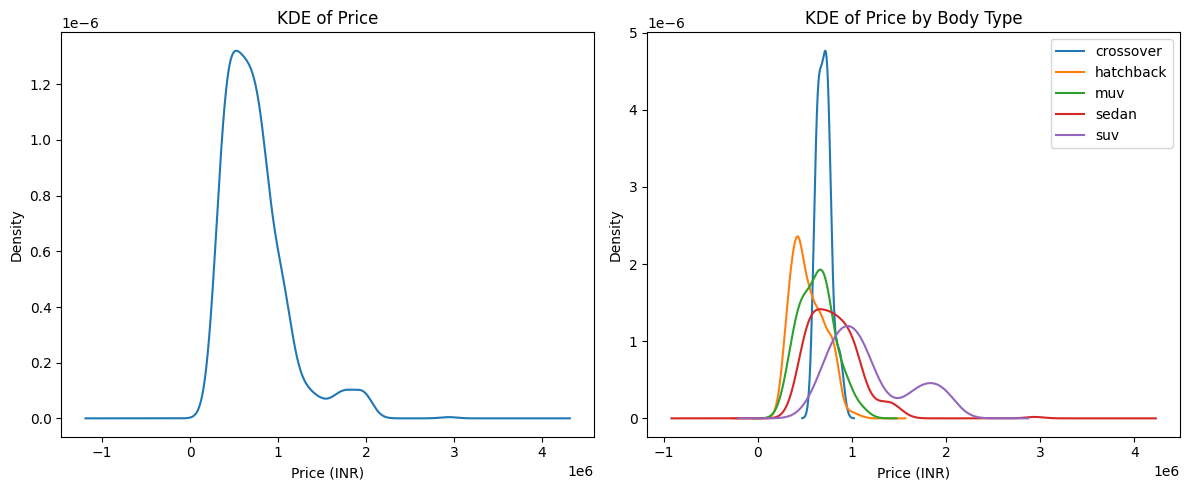

In [113]:
#Q3.1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline


df = pd.read_csv('./undergrad_ml_assignments/data/cars_hw.csv')
df.columns = df.columns.str.strip()

print(df['Price'].describe())
print("\nBy Body Type:")
print(df.groupby('Body_Type')['Price'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Price'].plot.kde(ax=axes[0])
axes[0].set_title('KDE of Price')
axes[0].set_xlabel('Price (INR)')

for body, group in df.groupby('Body_Type'):
    group['Price'].plot.kde(ax=axes[1], label=body)
axes[1].set_title('KDE of Price by Body Type')
axes[1].set_xlabel('Price (INR)')
axes[1].legend()

plt.tight_layout()
plt.show()


**Q3.1 Answer:**

**SUVs are the most expensive car type on average and have the most variance, shown by their wide flat KDE curve, while hatchbacks are the cheapest and most consistent in price with a tall narrow KDE curve. The overall distribution is right-skewed, meaning most cars are affordable but a few luxury SUVS and sedans pull the tail upward.**

In [114]:
#Q3.2

X_cont = sm.add_constant(df['Seating_Capacity'])
model_cont = sm.OLS(df['Price'], X_cont).fit()
print(model_cont.summary())

seat_dummies = pd.get_dummies(df['Seating_Capacity'], drop_first=True).astype(int)
X_cat = sm.add_constant(seat_dummies)
model_cat = sm.OLS(df['Price'], X_cat).fit()
print(model_cat.summary())

print(df.groupby('Seating_Capacity')['Price'].mean().sort_index())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        20:13:13   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

**Q3.2 Answer:**

**Each additional seat is associated with a ₹59,270 increase in price on average. However, when treating seating capacity as categorical, the coefficients don't increase linearly. 6-seat cars are actually more expensive than 7-seat cars (₹1,644,000 vs ₹923,949). This suggests that the relationship between seats and price is not truly linear and seat count alone is a poor predictor (R squared = 0.005).**

1     316694.442767
2     317513.181768
3     316828.286445
4     316977.019863
5     316435.374440
6     316777.154405
7     315926.056449
8     315198.835145
9     315657.046311
10    316066.889312
dtype: float64

Optimal degree: 8


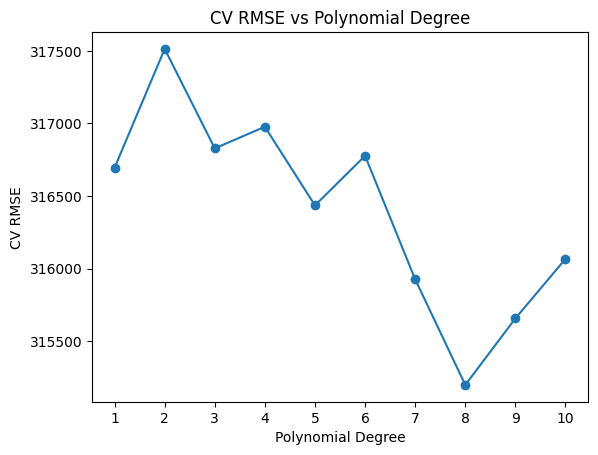

In [115]:
#Q3.3

df.columns = df.columns.str.strip()
df['Age'] = 2024 - df['Make_Year']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

cv_scores = {}

for degree in range(1, 11):
    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )
    scores = cross_val_score(model, df[['Age']], df['Price'],
                             cv=10, scoring='neg_mean_squared_error')
    cv_scores[degree] = np.sqrt(-scores.mean())

cv_df = pd.Series(cv_scores)
print(cv_df)
print(f"\nOptimal degree: {cv_df.idxmin()}")

cv_df.plot(marker='o')
plt.xlabel('Polynomial Degree')
plt.ylabel('CV RMSE')
plt.title('CV RMSE vs Polynomial Degree')
plt.xticks(range(1, 11))
plt.show()

**Q3.3 Answer:**

**Using 10-fold cross validation, the optimal polynomial degree for Age is 8 as it gives the lowest CV RSME of 315,199 INR. However, the RSME barely changes across all degrees (ranging only from ~315,199 to ~317,512), which tells us that age alone is a weak predictor of price. It adds more complexity and doesn't meaningfully improve predictions.**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


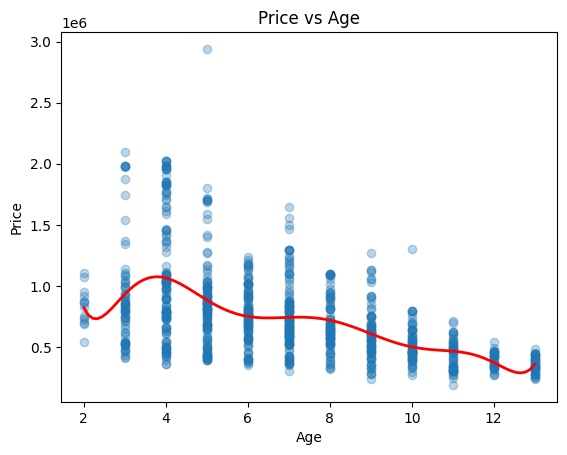

In [116]:
#Q3.4

plt.scatter(df['Age'], df['Price'], alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Price vs Age')

best_degree = cv_df.idxmin()

model = make_pipeline(
    PolynomialFeatures(best_degree),
    LinearRegression()
)

X = df[['Age']]
y = df['Price']

model.fit(X, y)

age_grid = np.linspace(df['Age'].min(), df['Age'].max(), 100).reshape(-1, 1)
preds = model.predict(age_grid)

plt.plot(age_grid, preds, color='red', linewidth=2)
plt.show()

**Q3.4 Answer:**

**The plot shows that car prices generally decrease as age increases, which makes sense due to depreciation. However, there is a lot of variation in prices of cars for the same age, so age alone is not a strong predictor. The degree 8 model creates a wavy curve that seems to overfit the data rather than capture a clear pattern. Overall, the model does not fit the data very well, suggesting that other variables are needed to better predict price.**

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [117]:
#Question 4 setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression


df = pd.read_csv('./undergrad_ml_assignments/data/heart_hw.csv')
df.columns = df.columns.str.strip()

df['treat'] = (df['transplant'] == 'treatment').astype(int)

In [118]:
df.head()

,Unnamed: 0,age,transplant,y,treat
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [119]:
#Q4.1

control_mean = df[df['treat'] == 0]['y'].mean()
treatment_mean = df[df['treat'] == 1]['y'].mean()

ATE = treatment_mean - control_mean

print("Control survival rate:", control_mean)
print("Treatment survival rate:", treatment_mean)
print("ATE:", ATE)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


**Q4.1 Answer:**

**The proportion of people who survive in the control group is 0.118, and in the treatment group is 0.348. The average treatment effect is 0.230, meaning that receiving a heart transplant increases the probability of surviving three years by about 23 percentage points on average.**

In [120]:
#Q4.2

X = sm.add_constant(df['treat'])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        20:13:14   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

**Q4.2 Answer:**

**The intercept is about 0.118, which matches the survival rate of the control group from part 1. The transplant coefficient is about 0.230, which matches the ATE. This shows that the regression is just reproducing the same values as the group averages, where the intercept represents the control group and the coefficient represents the difference between treatment and control.**

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        20:13:14   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

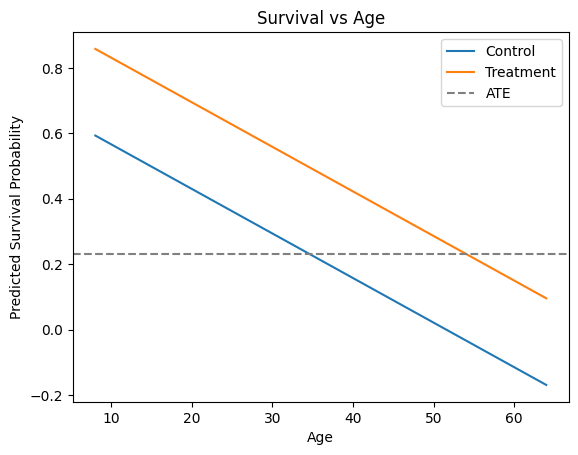

In [121]:
#Q4.3

X = sm.add_constant(df[['treat', 'age']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

age_grid = np.linspace(df['age'].min(), df['age'].max(), 100)

pred_control_df = pd.DataFrame({
    'const': 1,
    'treat': 0,
    'age': age_grid
})
pred_control = model.predict(pred_control_df)


pred_treat_df = pd.DataFrame({
    'const': 1,
    'treat': 1,
    'age': age_grid
})
pred_treat = model.predict(pred_treat_df)

plt.plot(age_grid, pred_control, label='Control')
plt.plot(age_grid, pred_treat, label='Treatment')
plt.axhline(y=ATE, linestyle='--', color='gray', label='ATE')
plt.xlabel('Age')
plt.ylabel('Predicted Survival Probability')
plt.legend()
plt.title('Survival vs Age')
plt.show()

**Q4.3 Answer:**

**After controlling for age, the transplant coefficient increases (approximately 0.265), showing age was affecting the original estimate. The intercept represents survival for a control patient at age 0, and the negative age coefficient means survival decreases with age. The plot shows both groups decline with age, with a constant gap between them. The ATE overestimates the effect for younger patients and underestimates it for older patients, so the effect varies by age.**

In [122]:
#Q4.4

df['interaction'] = df['treat'] * df['age']

X = sm.add_constant(df[['treat', 'age', 'interaction']])
model = sm.OLS(df['y'], X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        20:13:14   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.3549      0.280      1.269      

**Q4.4 Answer:**

**Allowing transplant and age to interact changes the predictions by making the treatment effect vary with age instead of staying constant. The model now shows that the benefit of a transplant decreases as age increases, meaning younger patients benefit more than older patients. The pattern is that the gap between treatment and control shrinks with age, giving a more realistic picture than the previous model.**

In [123]:
#Q4.5

X1 = df[['treat']]

X2 = df[['treat', 'age']]

X3 = df[['treat', 'age', 'interaction']]

y = df['y']

model = LinearRegression()

cv1 = -cross_val_score(model, X1, y, cv=10, scoring='neg_mean_squared_error').mean()
cv2 = -cross_val_score(model, X2, y, cv=10, scoring='neg_mean_squared_error').mean()
cv3 = -cross_val_score(model, X3, y, cv=10, scoring='neg_mean_squared_error').mean()

print("Model 1 (treat):", cv1)
print("Model 2 (treat + age):", cv2)
print("Model 3 (interaction):", cv3)

Model 1 (treat): 0.20970277289824915
Model 2 (treat + age): 0.19922806049232317
Model 3 (interaction): 0.19609811380122735


**Q4.5 Answer:**

**The model with only transplant has the highest error, while adding age improves performance. The interaction model has the lowest error, meaning it predicts survival best. This shows that including both age and the interaction captures more information and improves predictive accuracy**

**Q4.6 Answer:**

**A major concern is that the model could be biased if that data is not representative, which could lead to unfair decisions about who gets a transplant. It may also disadvantage older or higher-risk patients since it simplifies survival into a prediction. Additionally, the model ignores many important medical factors, so relying on it alone could lead to poor or unethical decisions.**